In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore, kruskal # kruskal might be useful later, zscore for this task
# For Windrose (if not installed: pip install windrose)
from windrose import WindroseAxes

# Configure plot styles for better visualization
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6) # Default figure size
plt.rcParams['figure.dpi'] = 100 # High resolution for plots

In [8]:
import os
print(os.getcwd())

d:\10academy\phase0\Ai10academy\notebooks


In [11]:
# Path to the raw data file (assuming notebook is in 'notebooks' and data is in 'data')
file_path = '../data/' + 'benin-malanville.csv' # temporarily breaking it up
df_benin = pd.read_csv(file_path)

print("Original DataFrame Info:")
df_benin.info()
print("\nFirst 5 rows of the dataset:")
print(df_benin.head())

Original DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525600 entries, 0 to 525599
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Timestamp      525600 non-null  object 
 1   GHI            525600 non-null  float64
 2   DNI            525600 non-null  float64
 3   DHI            525600 non-null  float64
 4   ModA           525600 non-null  float64
 5   ModB           525600 non-null  float64
 6   Tamb           525600 non-null  float64
 7   RH             525600 non-null  float64
 8   WS             525600 non-null  float64
 9   WSgust         525600 non-null  float64
 10  WSstdev        525600 non-null  float64
 11  WD             525600 non-null  float64
 12  WDstdev        525600 non-null  float64
 13  BP             525600 non-null  int64  
 14  Cleaning       525600 non-null  int64  
 15  Precipitation  525600 non-null  float64
 16  TModA          525600 non-null  float64
 17  TMod

In [12]:
print("\nDescriptive Statistics for Numeric Columns:")
print(df_benin.describe())


Descriptive Statistics for Numeric Columns:
                 GHI            DNI            DHI           ModA  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      240.559452     167.187516     115.358961     236.589496   
std       331.131327     261.710501     158.691074     326.894859   
min       -12.900000      -7.800000     -12.600000       0.000000   
25%        -2.000000      -0.500000      -2.100000       0.000000   
50%         1.800000      -0.100000       1.600000       4.500000   
75%       483.400000     314.200000     216.300000     463.700000   
max      1413.000000     952.300000     759.200000    1342.300000   

                ModB           Tamb             RH             WS  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      228.883576      28.179683      54.487969       2.121113   
std       316.536515       5.924297      28.073069       1.603466   
min         0.000000      11.000000       2.100000       

In [13]:
print("\nMissing Values Report:")
missing_values = df_benin.isnull().sum()
missing_percentage = (missing_values / len(df_benin)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})

# Sort by percentage descending
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

print(missing_df)

# List columns with >5% nulls
high_null_cols = missing_df[missing_df['Missing Percentage'] > 5].index.tolist()
if high_null_cols:
    print(f"\nColumns with more than 5% missing values: {high_null_cols}")
else:
    print("\nNo columns with more than 5% missing values.")


Missing Values Report:
          Missing Count  Missing Percentage
Comments         525600               100.0

Columns with more than 5% missing values: ['Comments']



Checking for non-physical values (e.g., negative GHI, DNI, DHI):
Column 'GHI' has 258847 negative values. These should be addressed.
Column 'DNI' has 275987 negative values. These should be addressed.
Column 'DHI' has 259182 negative values. These should be addressed.


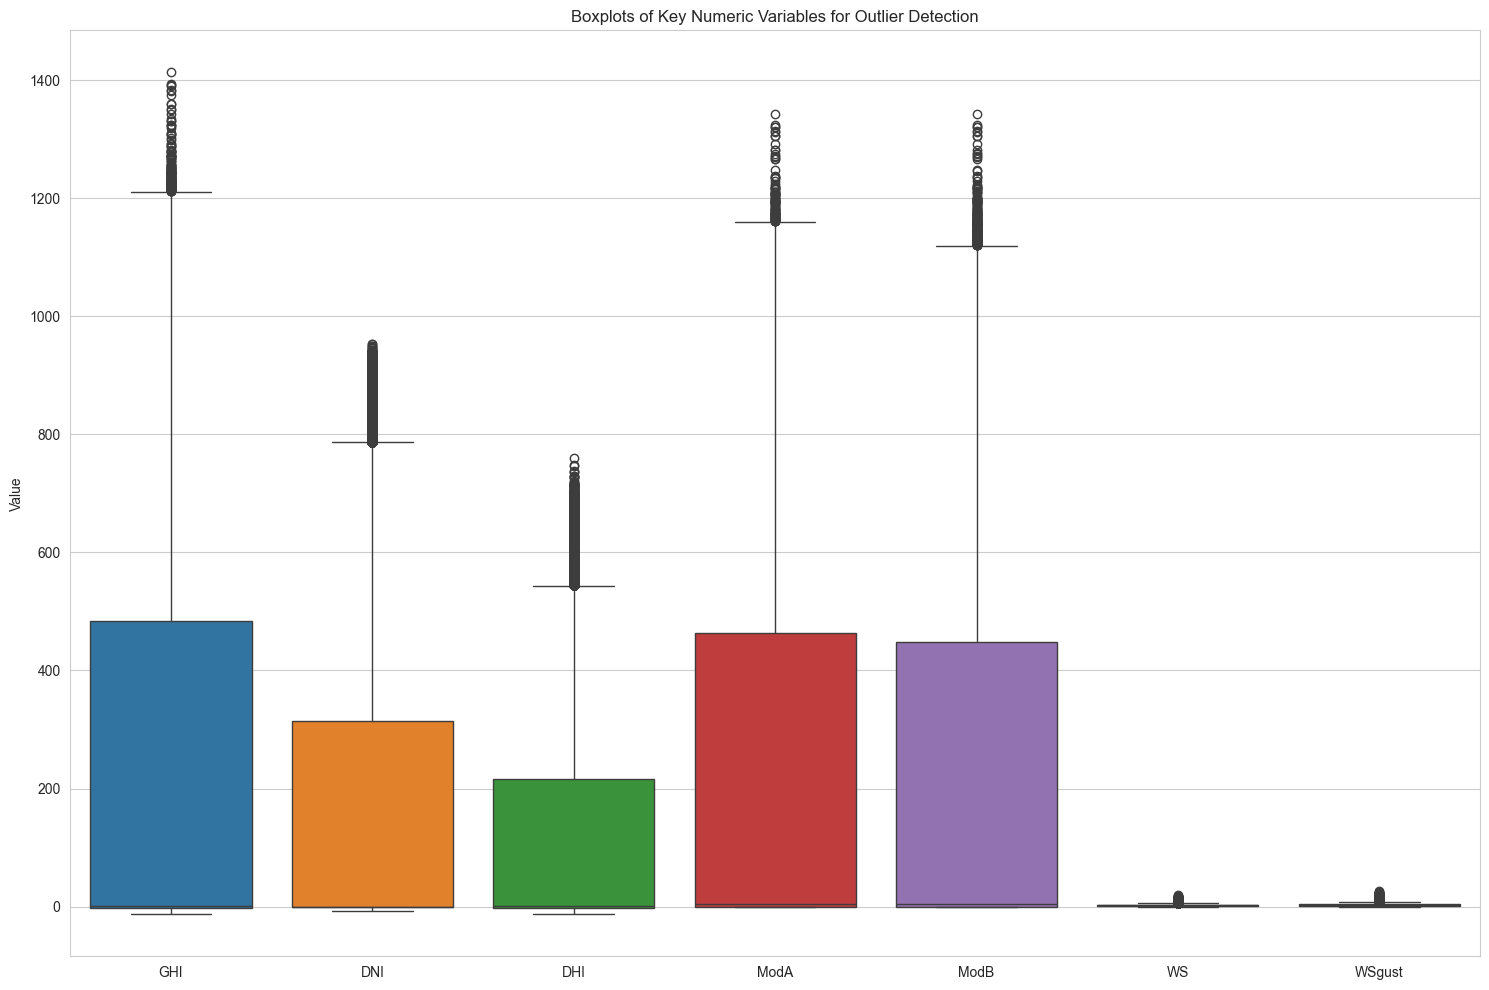

In [14]:
# Convert 'Timestamp' to datetime objects and set as index
df_benin['Timestamp'] = pd.to_datetime(df_benin['Timestamp'])
df_benin = df_benin.set_index('Timestamp')

# Quick check for non-physical values (e.g., negative solar irradiance)
print("\nChecking for non-physical values (e.g., negative GHI, DNI, DHI):")
for col in ['GHI', 'DNI', 'DHI']:
    negative_values = df_benin[df_benin[col] < 0][col].count()
    if negative_values > 0:
        print(f"Column '{col}' has {negative_values} negative values. These should be addressed.")

# Visualize distributions with boxplots for outlier detection
plt.figure(figsize=(15, 10))
sns.boxplot(data=df_benin[['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']])
plt.title('Boxplots of Key Numeric Variables for Outlier Detection')
plt.ylabel('Value')
plt.tight_layout()
plt.show()

In [15]:
outlier_cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']
df_benin_clean = df_benin.copy() # Work on a copy for cleaning

# Initialize an 'outlier_flag' column to False
df_benin_clean['outlier_flag'] = False

for col in outlier_cols:
    # Calculate Z-scores, handling NaNs
    # Store original values before potential imputation/dropping for cleaning impact analysis
    df_benin_clean[f'{col}_original'] = df_benin_clean[col]
    
    # Only calculate z-score for non-null values
    valid_data = df_benin_clean[col].dropna()
    if not valid_data.empty:
        z_scores = np.abs(zscore(valid_data))
        # Get the indices of outliers in the valid_data series
        outlier_indices = valid_data[z_scores > 3].index
        # Flag these rows in the main DataFrame
        df_benin_clean.loc[outlier_indices, 'outlier_flag'] = True
        print(f"Found {len(outlier_indices)} outliers in '{col}' (Z-score > 3).")
    else:
        print(f"Column '{col}' is entirely NaN, skipping Z-score calculation.")

total_flagged_outliers = df_benin_clean['outlier_flag'].sum()
print(f"\nTotal rows flagged as outliers across specified columns: {total_flagged_outliers}")

Found 89 outliers in 'GHI' (Z-score > 3).
Found 0 outliers in 'DNI' (Z-score > 3).
Found 3738 outliers in 'DHI' (Z-score > 3).
Found 27 outliers in 'ModA' (Z-score > 3).
Found 63 outliers in 'ModB' (Z-score > 3).
Found 3109 outliers in 'WS' (Z-score > 3).
Found 3500 outliers in 'WSgust' (Z-score > 3).

Total rows flagged as outliers across specified columns: 7740


In [16]:
# Handle negative solar irradiance values: set to 0 or NaN, then impute
for col in ['GHI', 'DNI', 'DHI']:
    df_benin_clean.loc[df_benin_clean[col] < 0, col] = np.nan # Convert negatives to NaN

# Impute missing values for key continuous variables with their median
impute_cols = ['GHI', 'DNI', 'DHI', 'Tamb', 'RH', 'BP', 'WS', 'WSgust', 'WD', 'ModA', 'ModB']
for col in impute_cols:
    if df_benin_clean[col].isnull().any():
        median_val = df_benin_clean[col].median()
        df_benin_clean[col].fillna(median_val, inplace=True)
        print(f"Imputed missing values in '{col}' with median: {median_val}")

# Drop rows flagged as outliers
initial_rows = len(df_benin_clean)
df_benin_clean = df_benin_clean[~df_benin_clean['outlier_flag']].copy() # Keep only non-outlier rows
rows_after_outlier_drop = len(df_benin_clean)
print(f"\nDropped {initial_rows - rows_after_outlier_drop} rows flagged as outliers.")

# Drop the temporary '_original' and 'outlier_flag' columns if no longer needed
df_benin_clean.drop(columns=[col for col in df_benin_clean.columns if '_original' in col or 'outlier_flag' in col], inplace=True, errors='ignore')

print("\nDataFrame after cleaning:")
df_benin_clean.info()

C:\Users\DELL 7020\AppData\Local\Temp\ipykernel_4188\3533472070.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_benin_clean[col].fillna(median_val, inplace=True)
C:\Users\DELL 7020\AppData\Local\Temp\ipykernel_4188\3533472070.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a co

Imputed missing values in 'GHI' with median: 474.2
Imputed missing values in 'DNI' with median: 345.7
Imputed missing values in 'DHI' with median: 213.4

Dropped 7740 rows flagged as outliers.

DataFrame after cleaning:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 517860 entries, 2021-08-09 00:01:00 to 2022-08-09 00:00:00
Data columns (total 18 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   GHI            517860 non-null  float64
 1   DNI            517860 non-null  float64
 2   DHI            517860 non-null  float64
 3   ModA           517860 non-null  float64
 4   ModB           517860 non-null  float64
 5   Tamb           517860 non-null  float64
 6   RH             517860 non-null  float64
 7   WS             517860 non-null  float64
 8   WSgust         517860 non-null  float64
 9   WSstdev        517860 non-null  float64
 10  WD             517860 non-null  float64
 11  WDstdev        517860 non-null  float64
 12  

In [17]:
output_path = '../data/benin_clean.csv'
df_benin_clean.to_csv(output_path, index=True) # index=True to save Timestamp as a column
print(f"\nCleaned data exported to {output_path}")


Cleaned data exported to ../data/benin_clean.csv


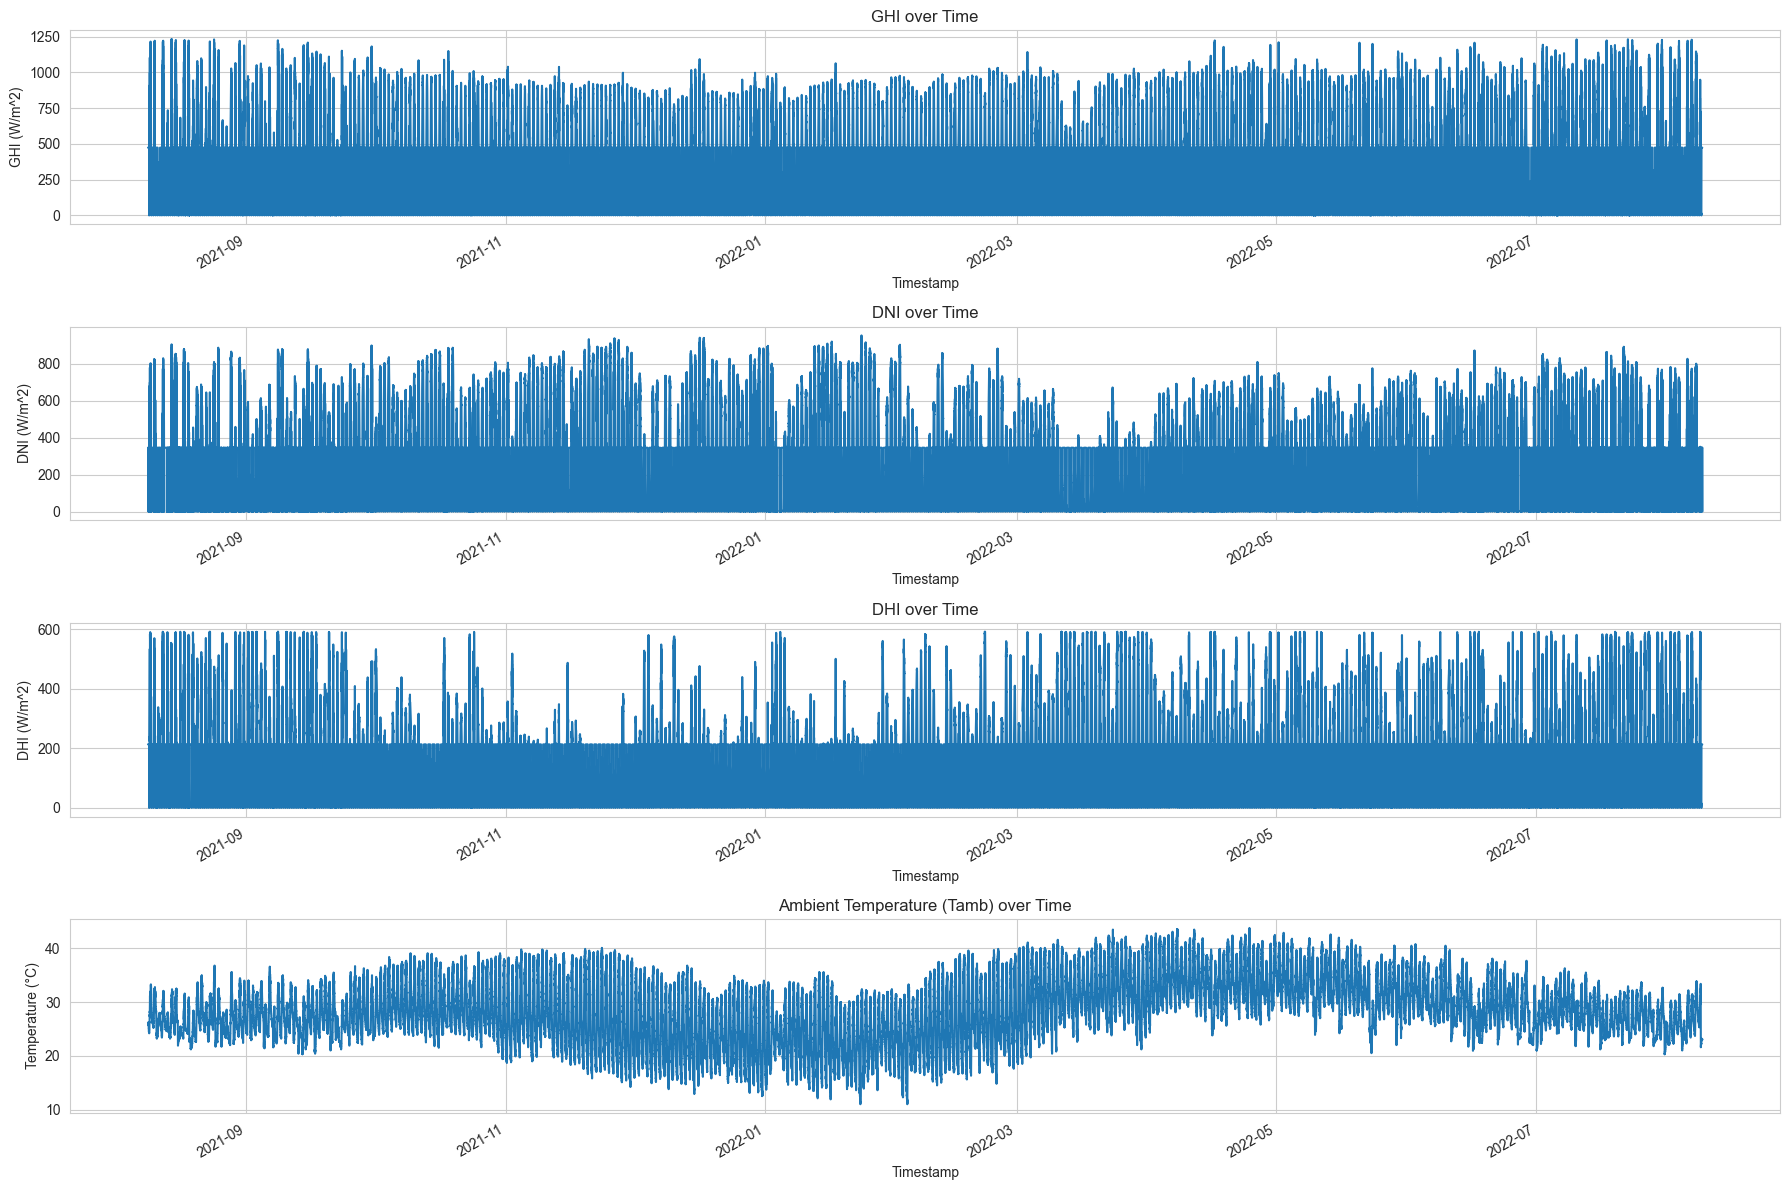

In [18]:
plt.figure(figsize=(18, 12))

plt.subplot(4, 1, 1)
df_benin_clean['GHI'].plot(title='GHI over Time')
plt.ylabel('GHI (W/m^2)')

plt.subplot(4, 1, 2)
df_benin_clean['DNI'].plot(title='DNI over Time')
plt.ylabel('DNI (W/m^2)')

plt.subplot(4, 1, 3)
df_benin_clean['DHI'].plot(title='DHI over Time')
plt.ylabel('DHI (W/m^2)')

plt.subplot(4, 1, 4)
df_benin_clean['Tamb'].plot(title='Ambient Temperature (Tamb) over Time')
plt.ylabel('Temperature (°C)')
plt.xlabel('Timestamp')

plt.tight_layout()
plt.show()

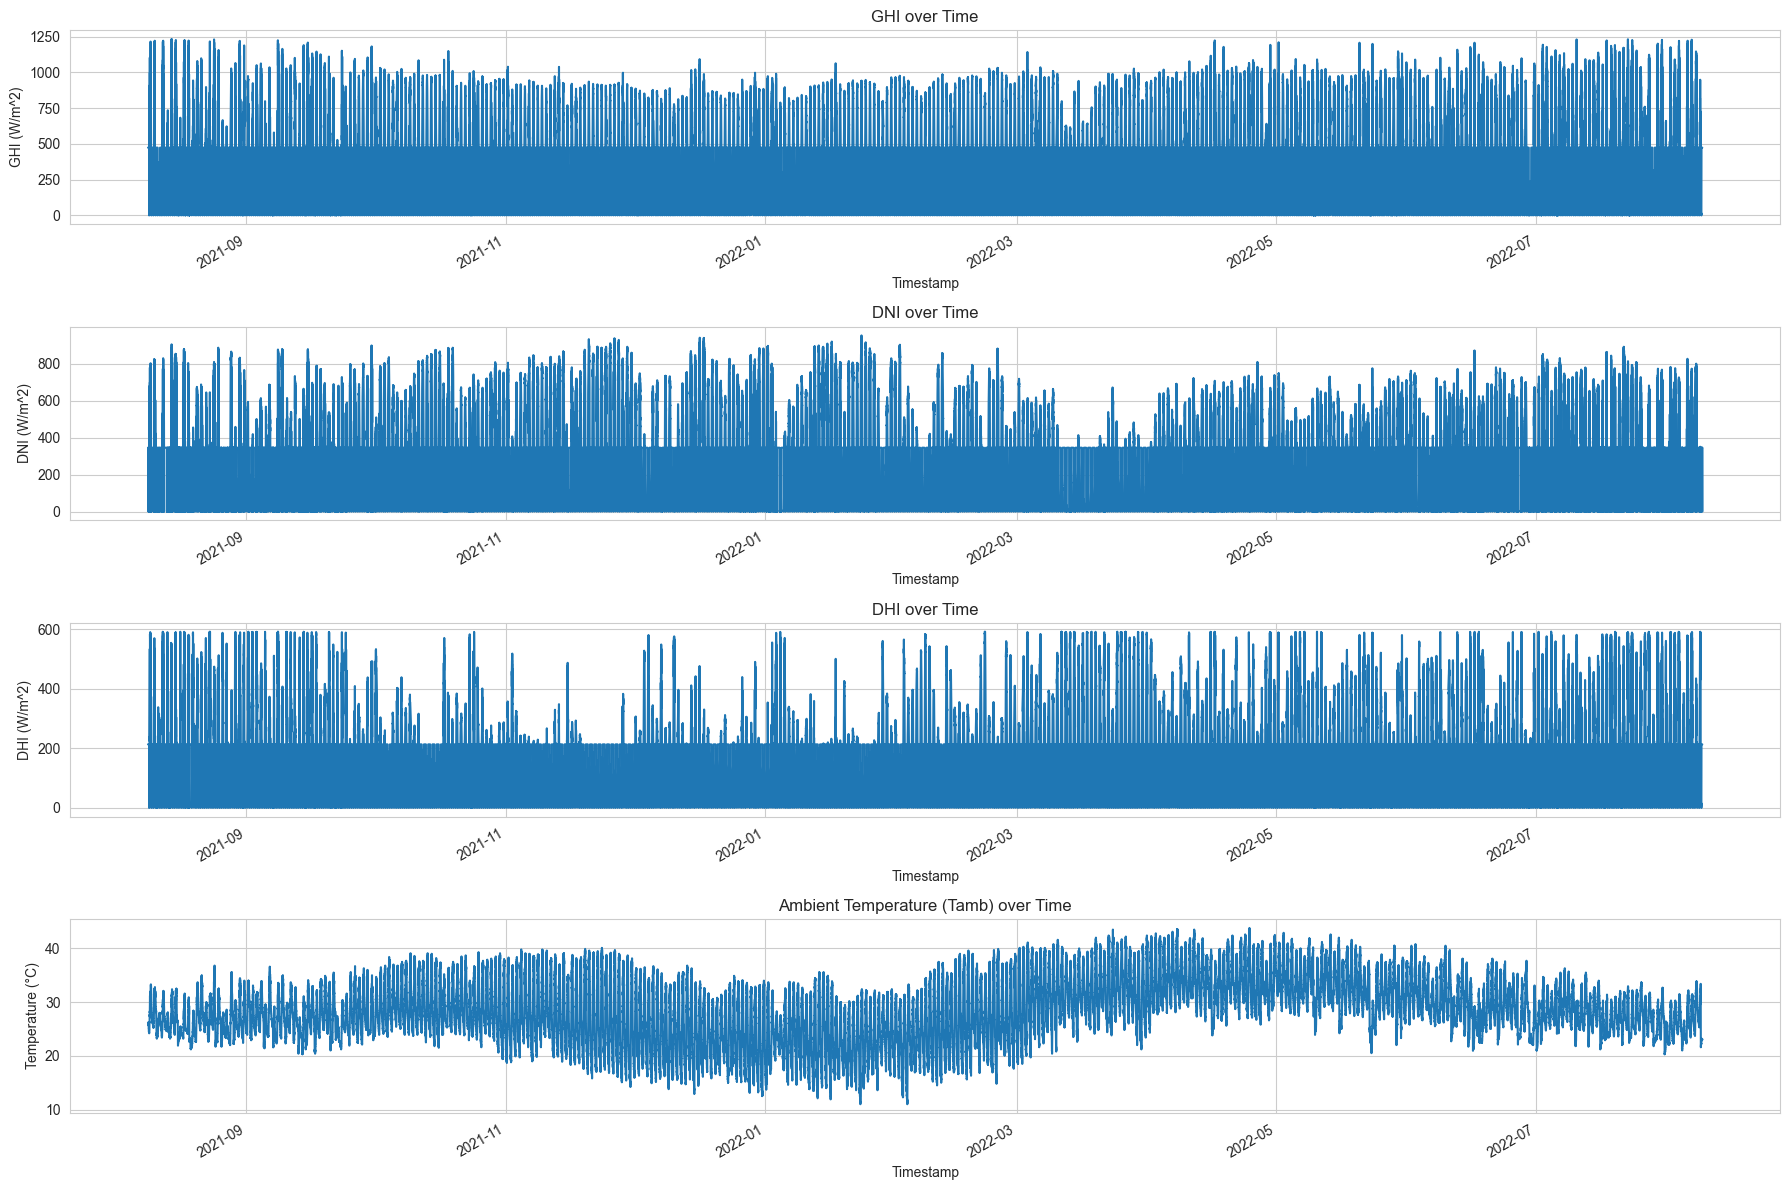

In [19]:
plt.figure(figsize=(18, 12))

plt.subplot(4, 1, 1)
df_benin_clean['GHI'].plot(title='GHI over Time')
plt.ylabel('GHI (W/m^2)')

plt.subplot(4, 1, 2)
df_benin_clean['DNI'].plot(title='DNI over Time')
plt.ylabel('DNI (W/m^2)')

plt.subplot(4, 1, 3)
df_benin_clean['DHI'].plot(title='DHI over Time')
plt.ylabel('DHI (W/m^2)')

plt.subplot(4, 1, 4)
df_benin_clean['Tamb'].plot(title='Ambient Temperature (Tamb) over Time')
plt.ylabel('Temperature (°C)')
plt.xlabel('Timestamp')

plt.tight_layout()
plt.show()

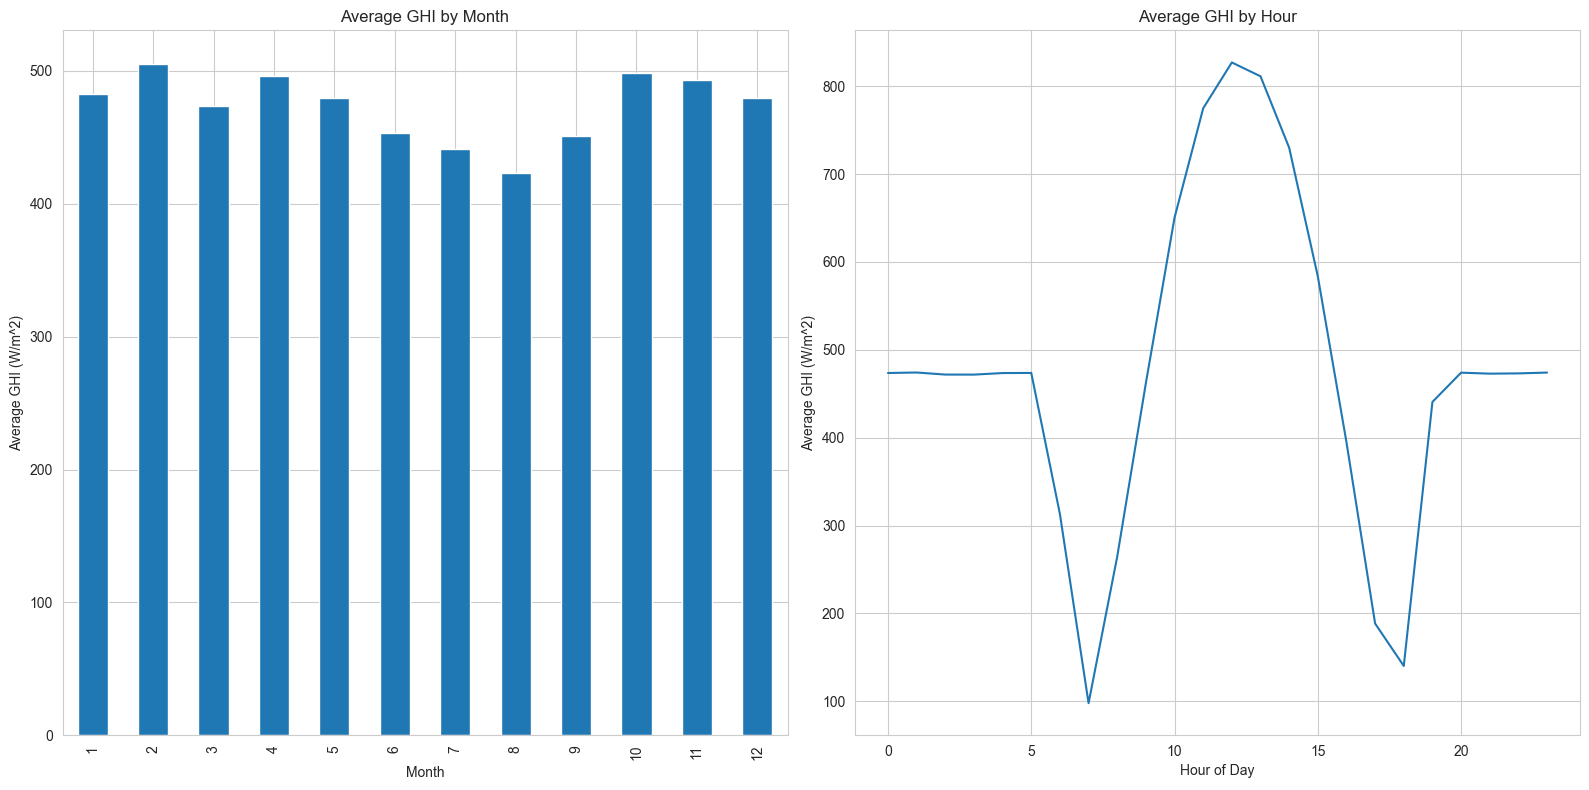

In [20]:
# Extract month and hour for pattern analysis
df_benin_clean['Month'] = df_benin_clean.index.month
df_benin_clean['Hour'] = df_benin_clean.index.hour

plt.figure(figsize=(16, 8))

# Monthly average GHI
plt.subplot(1, 2, 1)
df_benin_clean.groupby('Month')['GHI'].mean().plot(kind='bar')
plt.title('Average GHI by Month')
plt.xlabel('Month')
plt.ylabel('Average GHI (W/m^2)')

# Hourly average GHI
plt.subplot(1, 2, 2)
df_benin_clean.groupby('Hour')['GHI'].mean().plot(kind='line')
plt.title('Average GHI by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average GHI (W/m^2)')

plt.tight_layout()
plt.show()

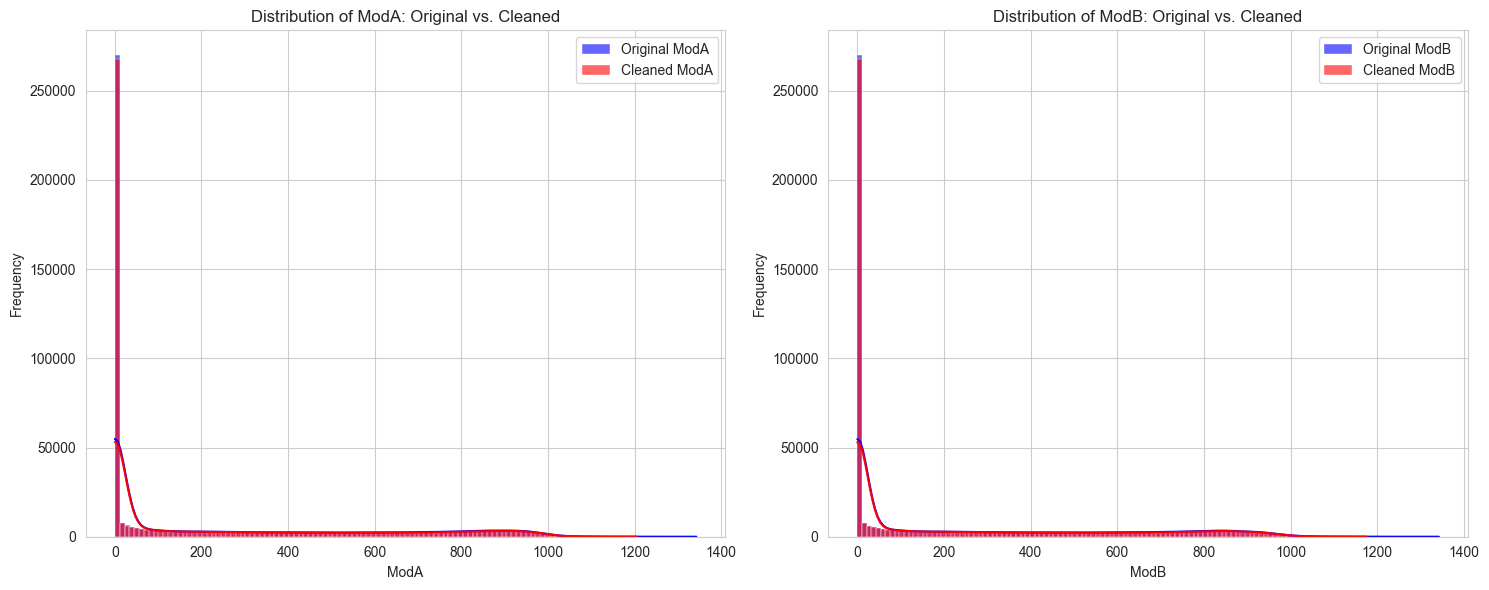


Summary Statistics for ModA (Original vs. Cleaned):
Original ModA:
 count    525600.000000
mean        236.589496
std         326.894859
min           0.000000
25%           0.000000
50%           4.500000
75%         463.700000
max        1342.300000
Name: ModA, dtype: float64

Cleaned ModA:
 count    517860.000000
mean        232.393310
std         324.256767
min           0.000000
25%           0.000000
50%           3.400000
75%         448.700000
max        1205.100000
Name: ModA, dtype: float64

Summary Statistics for ModB (Original vs. Cleaned):
Original ModB:
 count    525600.000000
mean        228.883576
std         316.536515
min           0.000000
25%           0.000000
50%           4.300000
75%         447.900000
max        1342.300000
Name: ModB, dtype: float64

Cleaned ModB:
 count    517860.000000
mean        225.026584
std         314.315996
min           0.000000
25%           0.000000
50%           3.200000
75%         434.000000
max        1175.000000
Name: ModB, d

In [21]:
# Re-load original data for comparison (or use the original df_benin before cleaning)
df_original_mod = pd.read_csv(file_path, parse_dates=['Timestamp']).set_index('Timestamp')

plt.figure(figsize=(15, 6))

# ModA comparison
plt.subplot(1, 2, 1)
sns.histplot(df_original_mod['ModA'].dropna(), color='blue', label='Original ModA', kde=True, alpha=0.6)
sns.histplot(df_benin_clean['ModA'], color='red', label='Cleaned ModA', kde=True, alpha=0.6)
plt.title('Distribution of ModA: Original vs. Cleaned')
plt.xlabel('ModA')
plt.ylabel('Frequency')
plt.legend()

# ModB comparison
plt.subplot(1, 2, 2)
sns.histplot(df_original_mod['ModB'].dropna(), color='blue', label='Original ModB', kde=True, alpha=0.6)
sns.histplot(df_benin_clean['ModB'], color='red', label='Cleaned ModB', kde=True, alpha=0.6)
plt.title('Distribution of ModB: Original vs. Cleaned')
plt.xlabel('ModB')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

# You can also look at summary statistics before/after for ModA and ModB
print("\nSummary Statistics for ModA (Original vs. Cleaned):")
print("Original ModA:\n", df_original_mod['ModA'].describe())
print("\nCleaned ModA:\n", df_benin_clean['ModA'].describe())

print("\nSummary Statistics for ModB (Original vs. Cleaned):")
print("Original ModB:\n", df_original_mod['ModB'].describe())
print("\nCleaned ModB:\n", df_benin_clean['ModB'].describe())

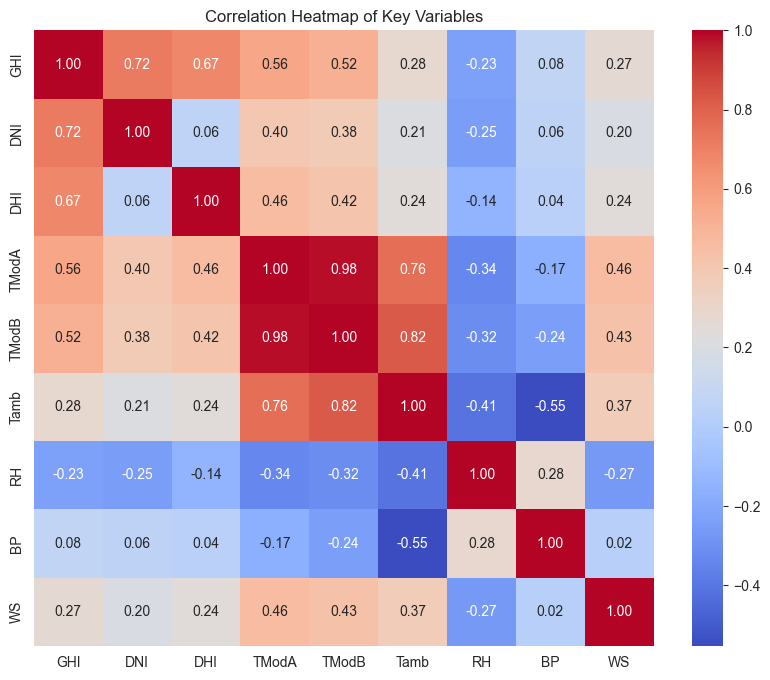

In [22]:
correlation_cols = ['GHI', 'DNI', 'DHI', 'TModA', 'TModB', 'Tamb', 'RH', 'BP', 'WS'] # Added more for richer insights
corr_matrix = df_benin_clean[correlation_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Key Variables')
plt.show()

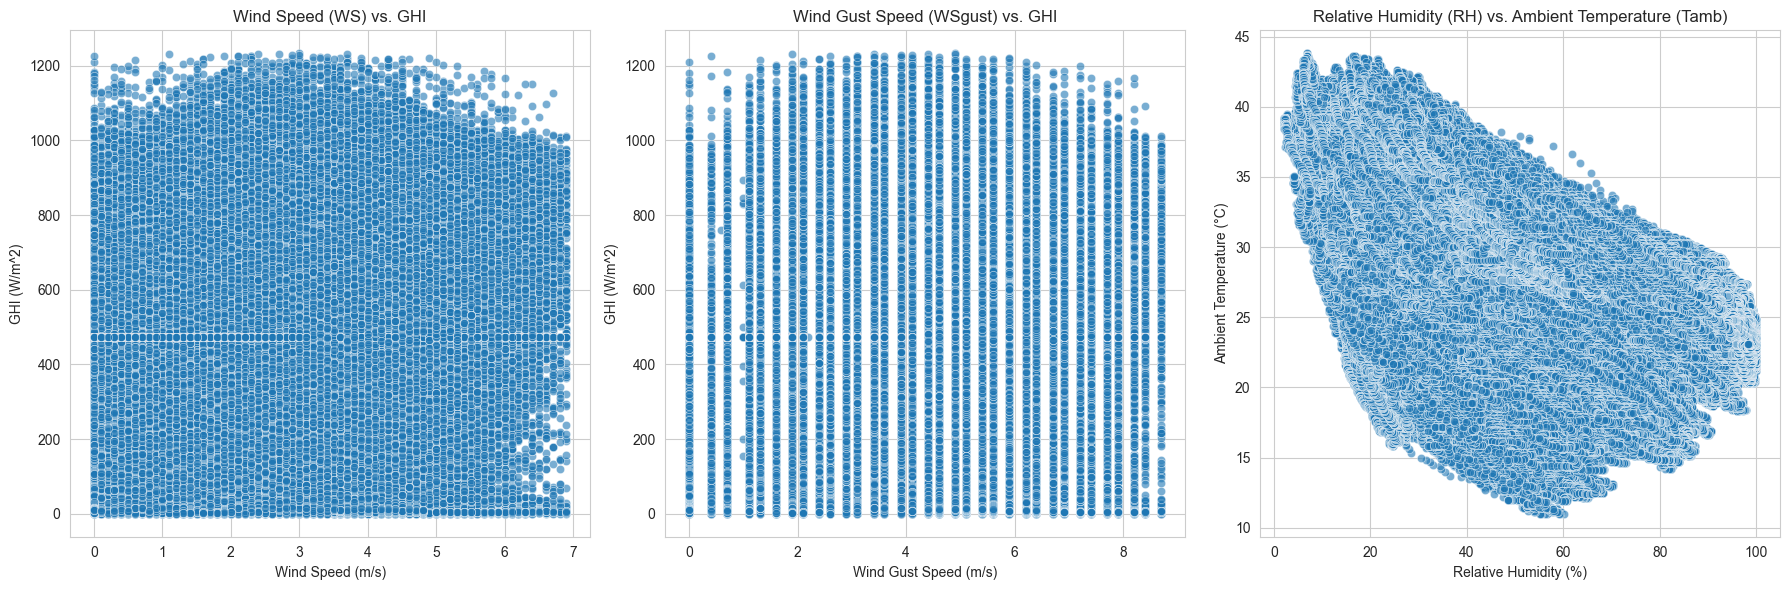

In [23]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.scatterplot(x='WS', y='GHI', data=df_benin_clean, alpha=0.6)
plt.title('Wind Speed (WS) vs. GHI')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('GHI (W/m^2)')

plt.subplot(1, 3, 2)
sns.scatterplot(x='WSgust', y='GHI', data=df_benin_clean, alpha=0.6)
plt.title('Wind Gust Speed (WSgust) vs. GHI')
plt.xlabel('Wind Gust Speed (m/s)')
plt.ylabel('GHI (W/m^2)')

plt.subplot(1, 3, 3)
sns.scatterplot(x='RH', y='Tamb', data=df_benin_clean, alpha=0.6)
plt.title('Relative Humidity (RH) vs. Ambient Temperature (Tamb)')
plt.xlabel('Relative Humidity (%)')
plt.ylabel('Ambient Temperature (°C)')

plt.tight_layout()
plt.show()

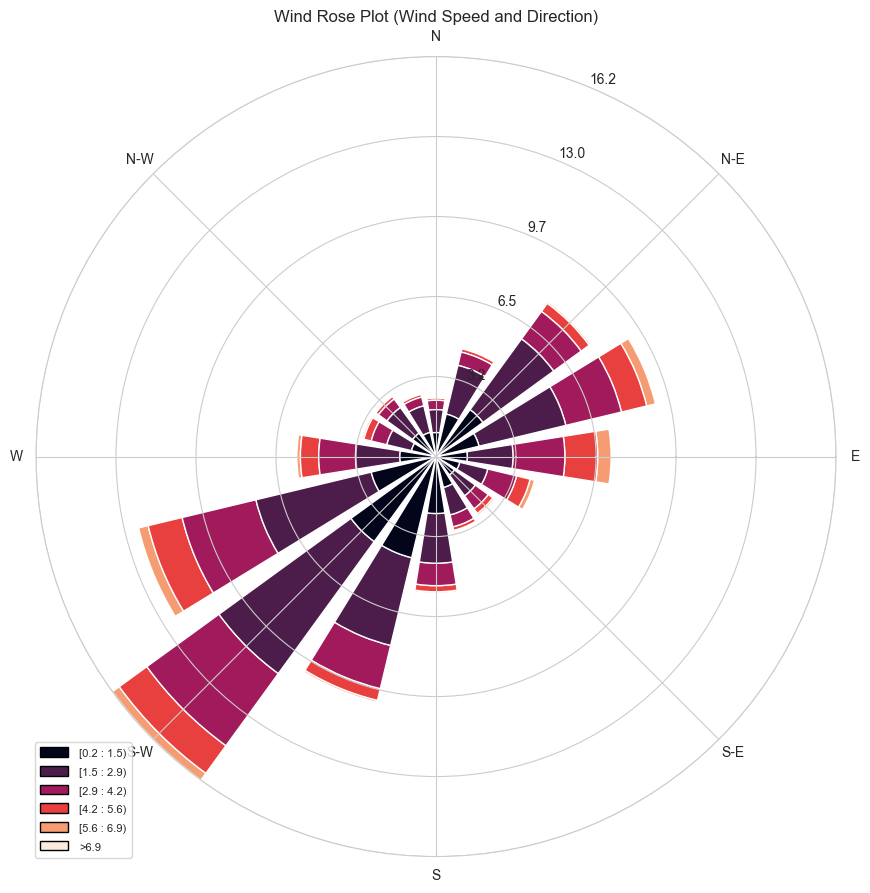

In [24]:
# Ensure WindroseAxes is imported and WS, WD are numeric
# Filter out zero wind speeds for clearer visualization in windrose
df_wind = df_benin_clean[(df_benin_clean['WS'] > 0.1) & (df_benin_clean['WD'].notna())].copy()

if not df_wind.empty:
    fig = plt.figure(figsize=(10, 10))
    ax = WindroseAxes.from_ax(fig=fig)
    ax.bar(df_wind['WD'], df_wind['WS'], normed=True, opening=0.8, edgecolor='white')
    ax.set_legend()
    plt.title('Wind Rose Plot (Wind Speed and Direction)')
    plt.show()
else:
    print("Not enough wind data with speed > 0.1 to plot wind rose.")

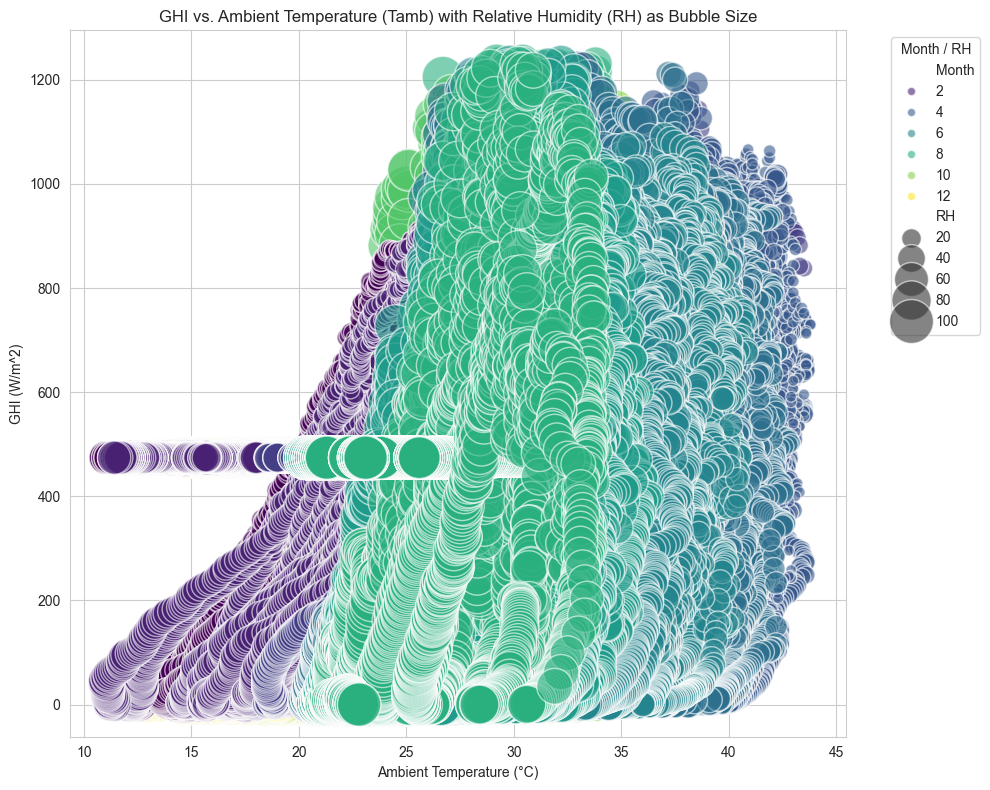

In [25]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Tamb',
    y='GHI',
    size='RH',       # Bubble size determined by Relative Humidity
    data=df_benin_clean,
    hue='Month',     # Optional: color by month for seasonal insight
    sizes=(20, 1000), # Min and max size of bubbles
    alpha=0.6,
    palette='viridis'
)
plt.title('GHI vs. Ambient Temperature (Tamb) with Relative Humidity (RH) as Bubble Size')
plt.xlabel('Ambient Temperature (°C)')
plt.ylabel('GHI (W/m^2)')
plt.legend(title='Month / RH', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()